In [1]:
import os

if os.getcwd().split("/")[-1] != "neurolib":
    os.chdir('..')

os.chdir('..')
datadir = os.path.join(os.getcwd(), "neurolib", "whole-brain")
print(datadir)

/home/lena/Promotion/neurolib/neurolib/whole-brain


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.io
import pickle

from neurolib.models.wc import WCModel
from neurolib.control.optimal_control import oc_wc, cost_functions

import nctpy.utils
import nctpy.metrics
import pandas as pd
import seaborn as sns
from scipy.signal import hilbert

# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2

import matplotlib as mpl
label_size= 20
mpl.rcParams['xtick.labelsize'] = label_size
mpl.rcParams['ytick.labelsize'] = label_size
mpl.rcParams['font.size'] = label_size
mpl.rcParams['axes.titlesize'] = label_size
mpl.rcParams['axes.titlesize'] = label_size
mpl.rcParams['figure.titlesize'] = label_size
mpl.rcParams['lines.linewidth'] = 1

In [3]:
N = 100

folders = ["NAP_002", "NAP_003", "NAP_005", "NAP_007", "NAP_009", "NAP_010", "NAP_011", "NAP_012", "NAP_013", "NAP_014", "NAP_015", "NAP_016", "NAP_018", "NAP_020", "NAP_022", "NAP_024", "NAP_025", "NAP_026", "NAP_027", "NAP_028", "NAP_029", "NAP_031", "NAP_032", "NAP_033", "NAP_035", "NAP_036"]
cmat_sum = np.zeros((N,N))
dmat_sum = np.zeros((N,N))

for f in folders:
    path = os.path.join(os.getcwd(), "data", "structural_data", "Sch100", f, "SC", "DTI_CM.mat")
    cmat_sum += scipy.io.loadmat(path)["SC"]
    path = os.path.join(os.getcwd(), "data", "structural_data", "Sch100", f, "SC", "DTI_LEN.mat")
    dmat_sum += scipy.io.loadmat(path)["LEN"]

cmat_av = cmat_sum/len(folders)
dmat_av = dmat_sum/len(folders)

wnd = np.sum(cmat_av, axis=0)
wnd_sorted = np.sort(wnd)

coord_data = pd.read_csv(os.path.join(os.getcwd(), "data", "structural_data", "Sch100_coords.txt"), sep=None, header=None).to_numpy()

colmap = mpl.cm.get_cmap('tab10')

/tmp/ipykernel_489331/1575196648.py:19: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support sep=None with delim_whitespace=False; you can avoid this warning by specifying engine='python'.
  coord_data = pd.read_csv(os.path.join(os.getcwd(), "data", "structural_data", "Sch100_coords.txt"), sep=None, header=None).to_numpy()
/tmp/ipykernel_489331/1575196648.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colmap = mpl.cm.get_cmap('tab10')


In [4]:
with open(os.path.join(datadir, 'wb_L1.pickle'), 'rb') as f:
    data_read = pickle.load(f)

d_var = data_read

with open(os.path.join(datadir, 'wb_L1_cc.pickle'), 'rb') as f:
    data_read = pickle.load(f)

d_cc = data_read

print(d_cc[0].keys())

dict_keys(['coordinates', 'weights', 'control', 'state', 'init_state', 'energy_input', 'sync_cost', 'state_uncontrolled'])


In [5]:
def get_phase(signal, range):
    analytic_signal = hilbert(signal)
    phase = np.angle(analytic_signal)

    minp, maxp = np.amin(phase[range[0]: range[1]]), np.amax(phase[range[0]: range[1]])
    phase -= minp
    phase *= 2.*np.pi/(maxp - minp)

    return phase

def get_kop(state):
    ko_= np.zeros((state.shape[1]), dtype=complex)
    phase_ = np.zeros_like( state,  dtype=complex)

    for n in range(N):
        phase_[n,:] = get_phase(state[n,:], [0,-1])
        ko_[:] += np.exp(complex(0,1)*phase_[n,:])

    ko_ /= N
    ko_ = np.abs(ko_)
    return ko_

def get_n_input_channels(control, lim=1e-3):
    n_ch = []
    for n in range(N):
        if np.sum(control[n,:]**2) > lim:
            n_ch.append(n)

    return n_ch

def setparams(model):
    model.params.c_excinh = 12  # local E-I coupling
    model.params.signalV = 80.0
    model.params.K_gl = 0.5  # global coupling strength
    model.params.a_exc = 1.  # excitatory gain
    model.params.a_inh = 1.  # inhibitory gain
    model.params.mu_exc = 5.0  # excitatory firing threshold
    model.params.mu_inh = 5.0  # inhibitory firing threshold

def simulate_get_kop(data, wi):
    duration = 700
    dt = 0.1
    model = WCModel(Cmat=cmat_av, Dmat=dmat_av, seed=0)
    model.params.duration = duration
    setparams(model)

    control = np.zeros((N, 1+int((duration)/dt)))
    if wi is not None:
        control[:,:4001] = data["control"][wi].copy()

    model.params.exc_ext_baseline = data["coordinates"][0]
    model.params.exc_inh_baseline = data["coordinates"][1]
    model.params.exc_init = data["init_state"][0]
    model.params.inh_init = data["init_state"][1]
    model.params.exc_ext = control.copy()
    model.run()
    kop = get_kop(model.exc[:,4000:])

    return kop   

----------------------- 0 0 ----------------
----------------------- 0 1 ----------------
----------------------- 0 2 ----------------
----------------------- 1 0 ----------------
----------------------- 1 1 ----------------
----------------------- 1 2 ----------------


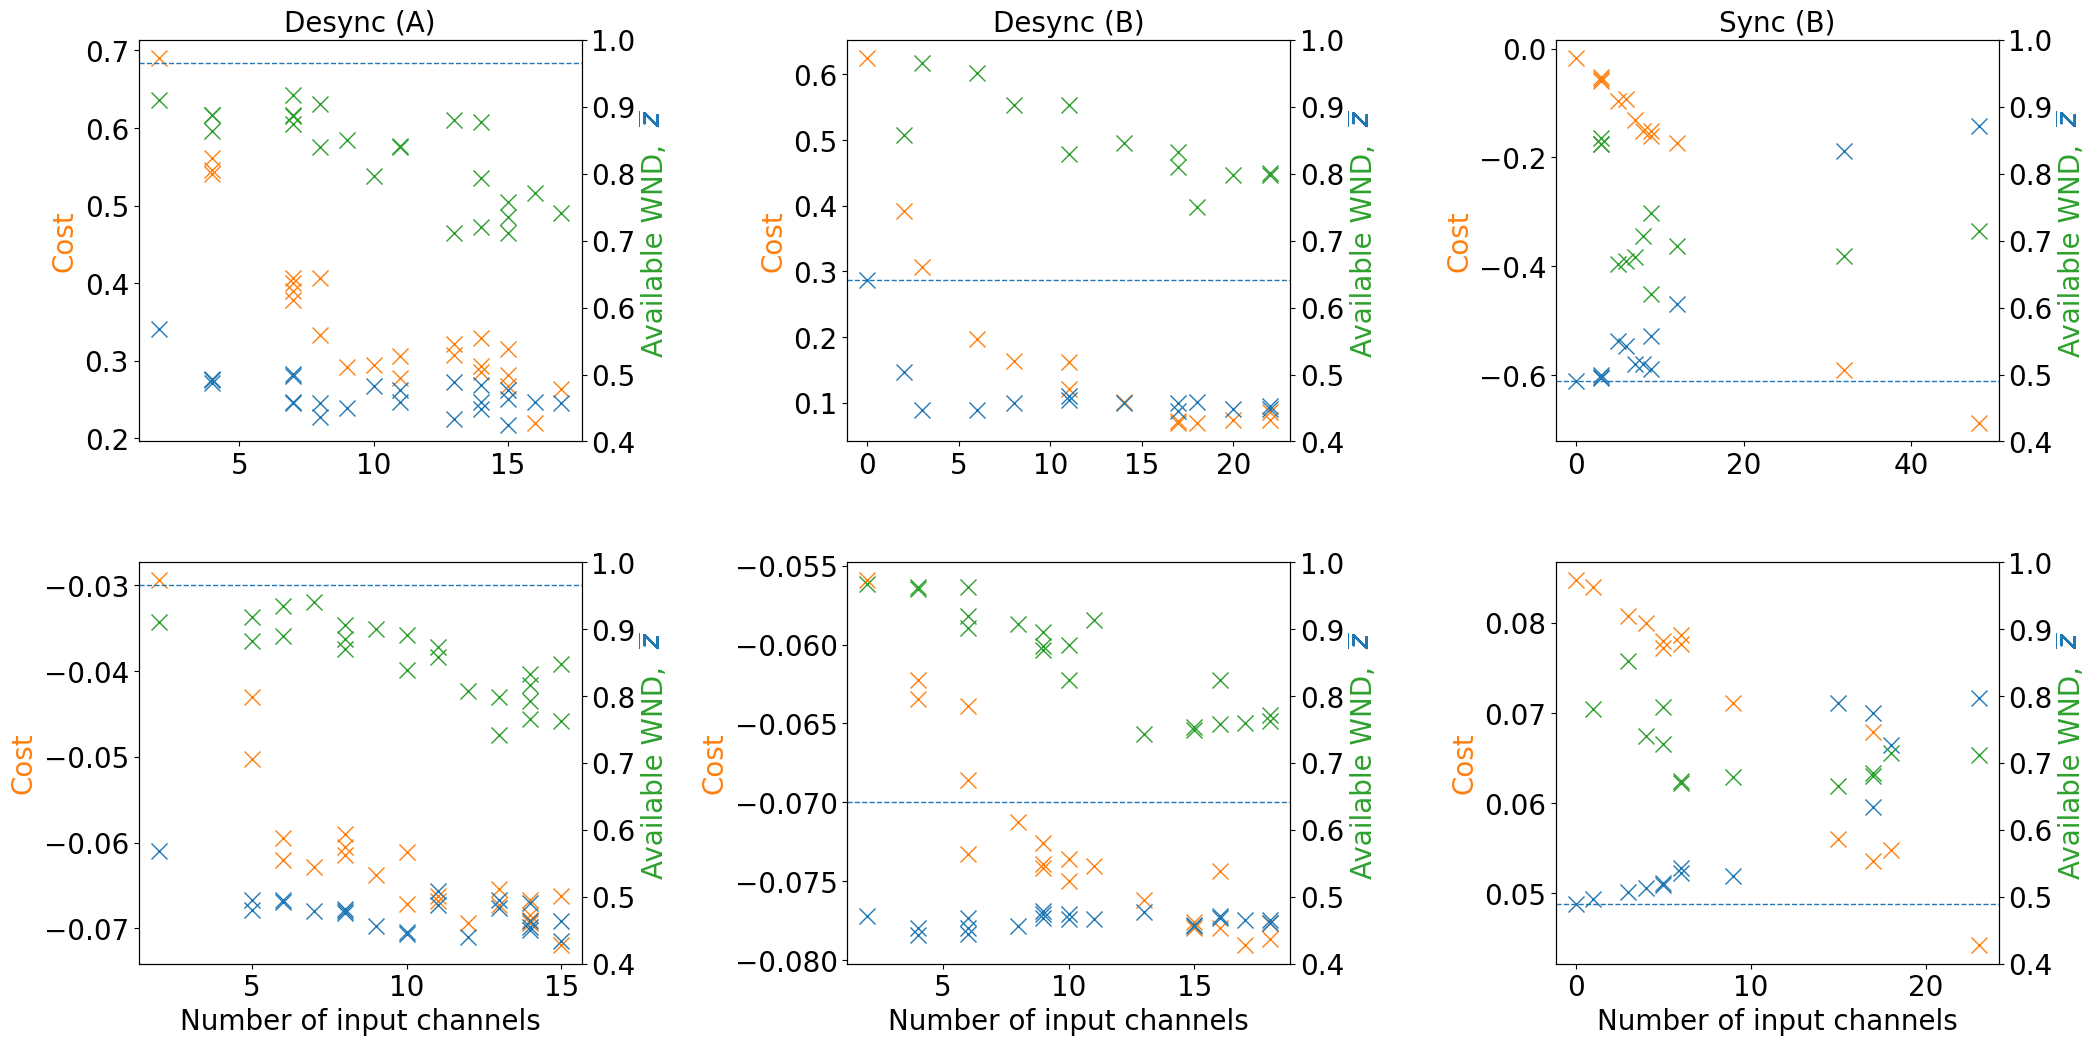

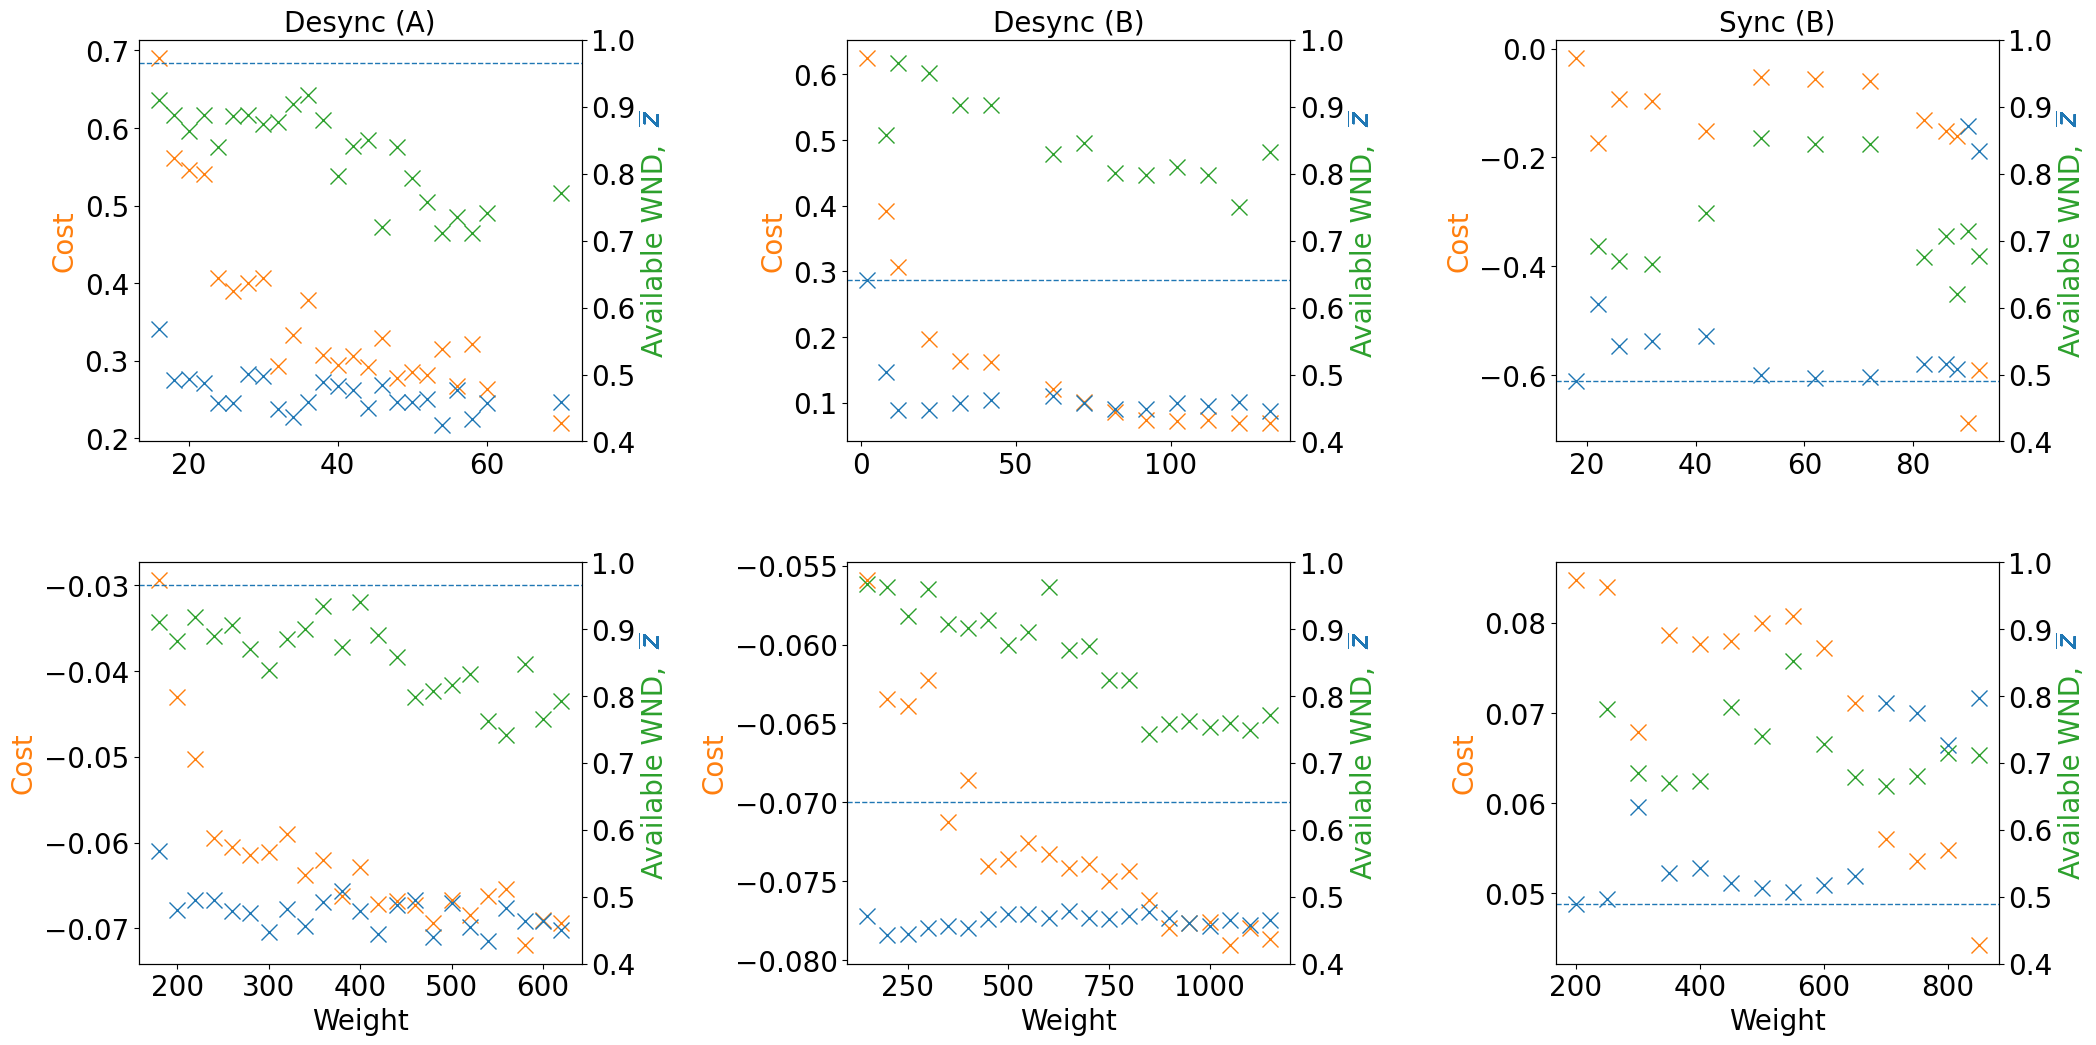

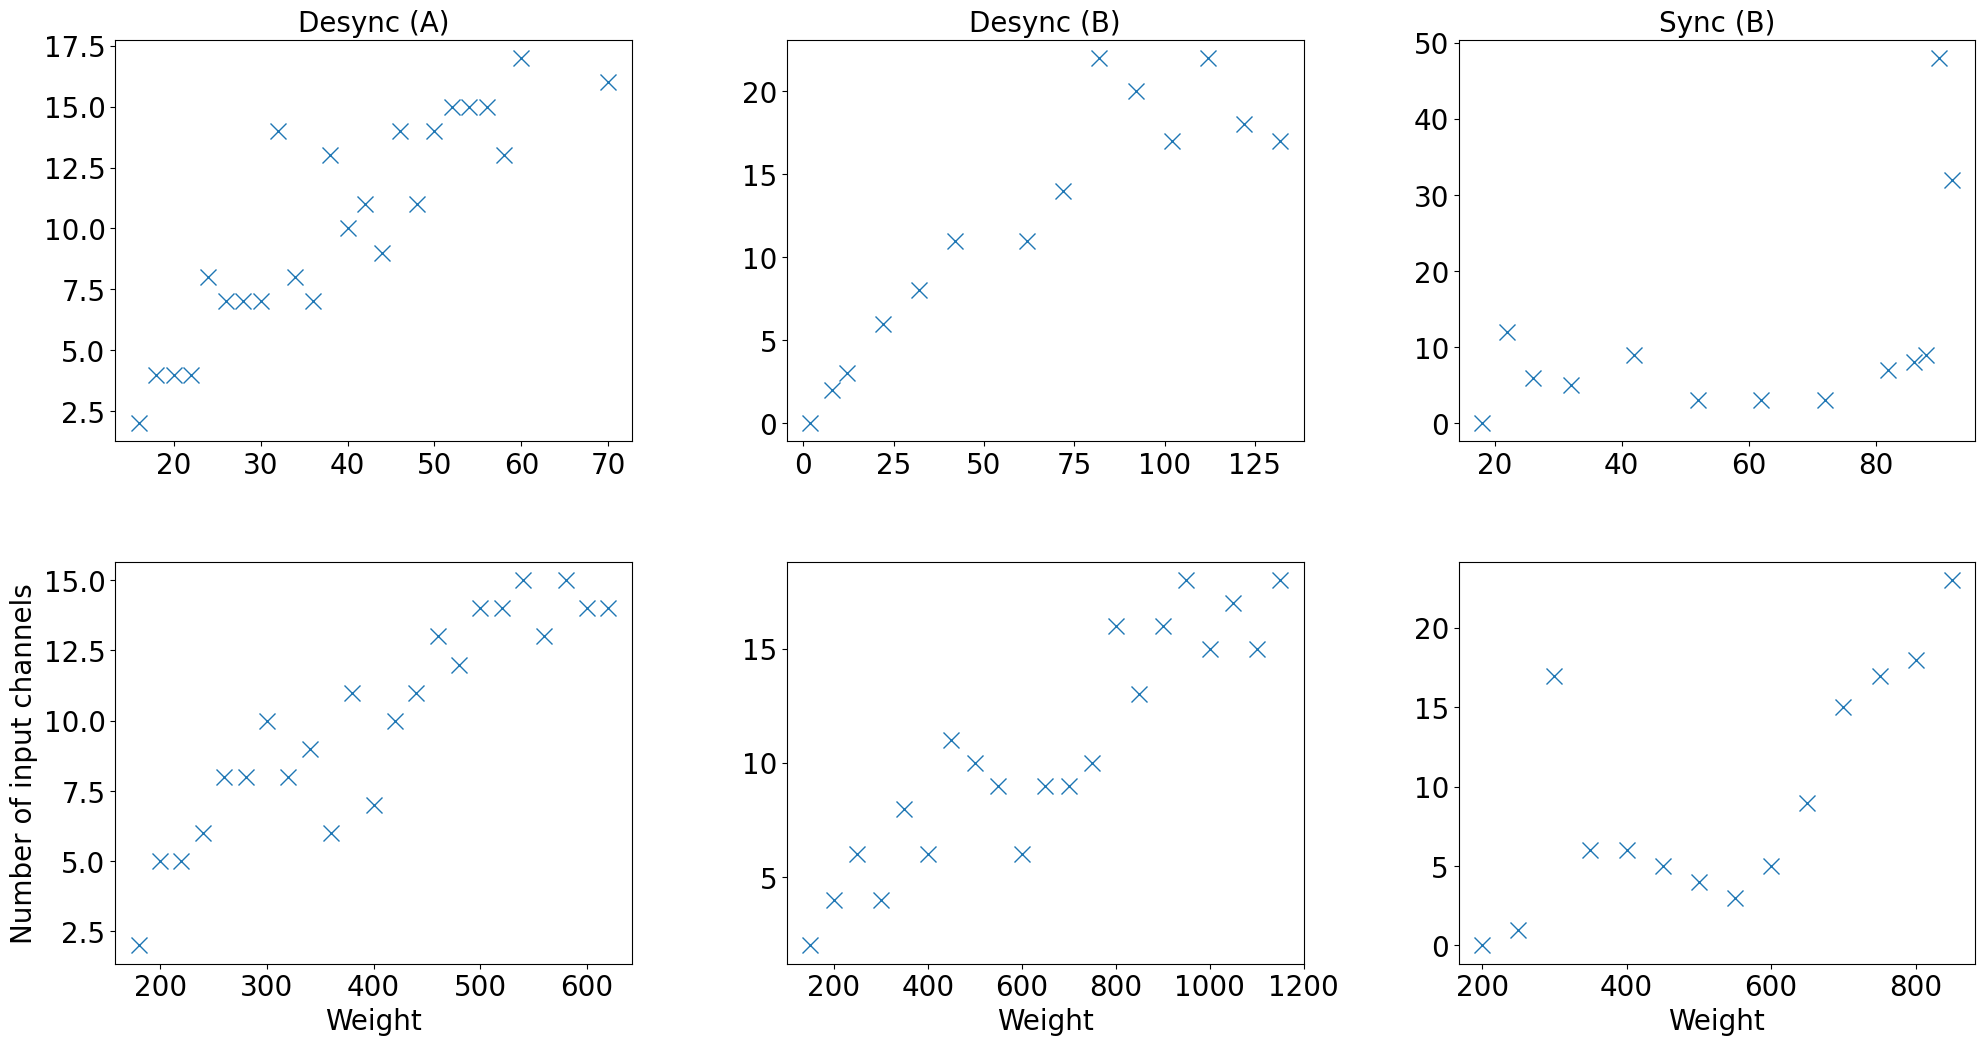

In [6]:
fig, ax = plt.subplots(2, 3, figsize=(24,12))
fig_, ax_ = plt.subplots(2, 3, figsize=(24,12))
fig__, ax__ = plt.subplots(2, 3, figsize=(24,12))

ms_ = 12


for di, d in enumerate([d_cc, d_var]):
    for ti, task in enumerate([2,0,1]):
        print("-----------------------", di, ti, "----------------")
        ax2 = ax[di,ti].twinx()
        ax2_ = ax_[di,ti].twinx()

        unc_kop = False

        for k in range(100):
            if d[task]["control"][k] is None: continue

            weight = np.abs(d[task]["weights"][k])
            channels = get_n_input_channels(d[task]["control"][k])
            sync_cost = d[task]["sync_cost"][k]
            kop = simulate_get_kop(d[task], k)

            ax__[di, ti].plot(weight, len(channels), marker="x", color=colmap(0.), markersize=ms_)

            if not unc_kop:
                unc_kop_ = simulate_get_kop(d[task], None)
                ax2.axhline(y=np.mean(unc_kop_), xmin=0,xmax=20, color=colmap(0), linestyle="--")
                ax2_.axhline(y=np.mean(unc_kop_), xmin=0,xmax=20, color=colmap(0), linestyle="--")
                unc_kop = True

            acc_wnd = np.sum(wnd[channels])
            max_acc_wnd = np.sum(wnd_sorted[-len(channels):])
            percentage_wnd = acc_wnd/max_acc_wnd

            if ti in [0,1]: sync_cost *= -1

            ax[di,ti].plot(len(channels), sync_cost, marker="x", color=colmap(0.1), markersize=ms_)
            ax2.plot(len(channels), np.mean(kop), marker="x", color=colmap(0), markersize=ms_)
            if len(channels) != 0:
                ax2.plot(len(channels), percentage_wnd, marker="x", color=colmap(0.2), markersize=ms_)
            ax2.set_ylim(0.4, 1)
            ax2.set_ylabel(r"Available WND,  ", color=colmap(0.2))
            ax2.text(1.13, 0.8, r"$\overline{z}$", color=colmap(0.0), rotation="vertical", transform=ax2.transAxes)

            ax_[di,ti].plot(weight, sync_cost, marker="x", color=colmap(0.1), markersize=ms_)
            ax2_.plot(weight, np.mean(kop), marker="x", color=colmap(0), markersize=ms_)
            if len(channels) != 0:
                ax2_.plot(weight, percentage_wnd, marker="x", color=colmap(0.2), markersize=ms_)
            ax2_.set_ylim(0.4, 1)
            ax2_.set_ylabel(r"Available WND,  ", color=colmap(0.2))
            ax2_.text(1.13, 0.8, r"$\overline{z}$", color=colmap(0.0), rotation="vertical", transform=ax2_.transAxes)

fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.6, hspace=0.3)
fig_.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.6, hspace=0.3)
fig__.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=0.3)

ax[0,0].set_title(r"Desync (A)")
ax[0,1].set_title(r"Desync (B)")
ax[0,2].set_title(r"Sync (B)")

ax_[0,0].set_title(r"Desync (A)")
ax_[0,1].set_title(r"Desync (B)")
ax_[0,2].set_title(r"Sync (B)")

ax__[0,0].set_title(r"Desync (A)")
ax__[0,1].set_title(r"Desync (B)")
ax__[0,2].set_title(r"Sync (B)")

for k in range(3):
    for j in range(2):
        ax[j,k].set_ylabel(r"Cost", color=colmap(0.1))
        ax_[j,k].set_ylabel(r"Cost", color=colmap(0.1))
    ax__[j,0].set_ylabel(r"Number of input channels")
    
    ax[j,k].set_xlabel(r"Number of input channels")
    ax__[j,k].set_xlabel(r"Weight")
    ax_[j,k].set_xlabel(r"Weight")

fig.savefig("l1_nnodes.pdf", bbox_inches='tight')
fig_.savefig("l1_weight.pdf", bbox_inches='tight')
fig__.savefig("l1_nnodes_weight.pdf", bbox_inches='tight')


plt.show()